In [ ]:
import os
import sys
import json
import time
import glob
import shutil
import textwrap
import subprocess
import importlib
from pathlib import Path
from getpass import getpass

REPO_URL = "https://github.com/ResearAI/AutoFigure.git"
REPO_DIR = Path("/content/AutoFigure")
OUTPUT_ROOT = Path("/content/autofigure_colab_outputs")

PROVIDER = os.environ.get("AUTOFIGURE_PROVIDER", "openrouter")

DEFAULT_MODELS = {
    "openrouter": "google/gemini-3.1-pro-preview",
    "gemini": "gemini-3.1-pro-preview",
    "bianxie": "gemini-3.1-pro-preview",
}

GENERATION_MODEL = os.environ.get(
    "AUTOFIGURE_MODEL",
    DEFAULT_MODELS.get(PROVIDER, "google/gemini-3.1-pro-preview")
)

MAX_ITERATIONS = int(os.environ.get("AUTOFIGURE_MAX_ITERATIONS", "1"))
QUALITY_THRESHOLD = float(os.environ.get("AUTOFIGURE_QUALITY_THRESHOLD", "8.5"))

RUN_TEXT_TO_FIGURE = True
RUN_PAPER_TO_FIGURE = False
RUN_MXGRAPH_DEMO = False
RUN_IMAGE_ENHANCEMENT = False

TEXT_OUTPUT_FORMAT = "svg"
MXGRAPH_OUTPUT_FORMAT = "mxgraphxml"

ART_STYLE = (
    "clean publication-ready scientific illustration, precise alignment, subtle shadows, "
    "clear academic typography, high contrast, minimal clutter"
)

FIGURE_DESCRIPTION = """
Create a publication-ready scientific method figure for an agentic long-document intelligence system.

The figure should explain the following pipeline in a left-to-right architecture:

1. Long documents enter the system. They may be PDFs, scanned reports, markdown files, tables, or mixed-layout documents.
2. A document normalization layer extracts raw text, section hierarchy, tables, figures, and metadata.
3. A routing planner decides whether each section should go to summarization, field extraction, table reconstruction, visual analysis, or citation grounding.
4. Specialized expert modules process the routed chunks:
   - Summarizer expert creates hierarchical summaries.
   - Extraction expert returns JSON fields.
   - Table expert reconstructs exact tables.
   - Visual expert describes charts and diagrams.
   - Citation expert links claims to evidence spans.
5. A low-cost orchestration layer selects smaller or larger LLMs depending on complexity, confidence, and budget.
6. A verification layer checks schema validity, source grounding, table consistency, and confidence.
7. The final output is an analyst-ready workspace containing a summary, extracted fields, exact tables, cited answers, and audit logs.

Design requirements:
- Use a wide 16:9 layout.
- Use clear module boxes, arrows, and labels.
- Add small callouts for cost control, confidence scoring, and auditability.
- Avoid decorative clutter.
- Make the flow understandable for a finance or enterprise document intelligence audience.
"""

MINI_PAPER_MARKDOWN = """
# Efficient Agentic Document Intelligence for Long Financial Reports

## Abstract
We propose an agentic document intelligence architecture for extracting summaries, facts, tables,
and grounded answers from long heterogeneous financial documents.

## Method
Our method first normalizes each incoming document into a structured document graph. The graph
contains section nodes, paragraph nodes, table nodes, figure nodes, and metadata nodes. A routing
planner assigns each node to a specialized expert according to modality, complexity, and required
output schema.

The system uses five experts. The summarization expert produces hierarchical summaries from
section-level chunks. The extraction expert fills strict JSON schemas for entities, dates, risks,
financial metrics, and obligations. The table expert reconstructs exact tables and validates row-column
alignment. The visual expert describes charts and diagrams. The citation expert maps every generated
claim to source spans.

A budget-aware orchestration layer selects model size dynamically. Simple chunks are processed by
low-cost models, while complex chunks are escalated to stronger models. A verification layer then
checks schema validity, citation support, numerical consistency, and table integrity. Failed checks are
routed back for repair.

## Experiments
We evaluate on financial filings and analyst reports using extraction accuracy, grounding precision,
table reconstruction quality, and total inference cost.
"""

def run(cmd, cwd=None, check=True, quiet=False):
    print(f"\n$ {cmd}")
    process = subprocess.run(
        cmd,
        shell=True,
        cwd=str(cwd) if cwd else None,
        text=True,
        stdout=subprocess.PIPE if quiet else None,
        stderr=subprocess.STDOUT if quiet else None,
    )
    if quiet and process.stdout:
        print(process.stdout[-5000:])
    if check and process.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {process.returncode}: {cmd}")
    return process

def heading(title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

def safe_read(path, max_chars=2500):
    path = Path(path)
    if not path.exists():
        return ""
    text = path.read_text(encoding="utf-8", errors="ignore")
    return text[:max_chars] + ("\n... [truncated]" if len(text) > max_chars else "")

def clear_loaded_modules(prefixes):
    for name in list(sys.modules):
        if any(name == prefix or name.startswith(prefix + ".") for prefix in prefixes):
            del sys.modules[name]

def get_colab_secret(names):
    try:
        from google.colab import userdata
        for name in names:
            try:
                value = userdata.get(name)
                if value:
                    return value
            except Exception:
                pass
    except Exception:
        pass
    return None

def collect_api_key(provider):
    env_candidates = [
        "AUTOFIGURE_API_KEY",
        "OPENROUTER_API_KEY",
        "GOOGLE_API_KEY",
        "GEMINI_API_KEY",
        "BIANXIE_API_KEY",
    ]

    for key_name in env_candidates:
        value = os.environ.get(key_name)
        if value:
            print(f"Using API key from environment variable: {key_name}")
            return value

    secret_candidates = {
        "openrouter": ["AUTOFIGURE_API_KEY", "OPENROUTER_API_KEY"],
        "gemini": ["AUTOFIGURE_API_KEY", "GOOGLE_API_KEY", "GEMINI_API_KEY"],
        "bianxie": ["AUTOFIGURE_API_KEY", "BIANXIE_API_KEY"],
    }.get(provider, ["AUTOFIGURE_API_KEY"])

    value = get_colab_secret(secret_candidates)
    if value:
        print("Using API key from Colab Secrets.")
        return value

    value = getpass(f"Paste your {provider} API key, or press Enter to skip cloud generation: ").strip()
    return value

In [ ]:
def display_file_if_possible(path, title=None):
    path = Path(path) if path else None
    if not path or not path.exists():
        print(f"Missing file: {path}")
        return

    try:
        from IPython.display import display, Image as IPImage, SVG, Markdown
        if title:
            display(Markdown(f"### {title}"))

        suffix = path.suffix.lower()

        if suffix == ".png":
            display(IPImage(filename=str(path)))
        elif suffix == ".svg":
            display(SVG(filename=str(path)))
        elif suffix in [".json", ".md", ".txt", ".drawio"]:
            print(safe_read(path, max_chars=5000))
        else:
            print(path)
    except Exception as exc:
        print(f"Could not display {path}: {exc}")

def make_output_gallery(output_dir):
    output_dir = Path(output_dir)
    gallery_path = output_dir / "gallery.html"

    blocks = []

    for p in sorted(output_dir.rglob("*.png")):
        rel = p.relative_to(output_dir)
        blocks.append(f"""
        <div class="card">
          <h3>{rel}</h3>
          <img src="{rel}" />
        </div>
        """)

    for p in sorted(output_dir.rglob("*.svg")):
        rel = p.relative_to(output_dir)
        svg_text = p.read_text(encoding="utf-8", errors="ignore")
        blocks.append(f"""
        <div class="card">
          <h3>{rel}</h3>
          <div class="svgbox">{svg_text}</div>
        </div>
        """)

    for p in sorted(output_dir.rglob("*.drawio")):
        rel = p.relative_to(output_dir)
        code = p.read_text(encoding="utf-8", errors="ignore")[:4000]
        blocks.append(f"""
        <div class="card">
          <h3>{rel}</h3>
          <p>Editable draw.io mxGraph XML file.</p>
          <pre>{code}</pre>
        </div>
        """)

    for p in sorted(output_dir.rglob("generation_report.json")):
        rel = p.relative_to(output_dir)
        try:
            report_text = json.dumps(json.loads(p.read_text(encoding="utf-8")), indent=2)[:7000]
        except Exception:
            report_text = p.read_text(encoding="utf-8", errors="ignore")[:7000]

        blocks.append(f"""
        <div class="card">
          <h3>{rel}</h3>
          <pre>{report_text}</pre>
        </div>
        """)

    html = f"""
    <!doctype html>
    <html>
    <head>
      <meta charset="utf-8">
      <title>AutoFigure Colab Gallery</title>
      <style>
        body {{
          font-family: Arial, sans-serif;
          margin: 24px;
          background: #f7f7f7;
        }}
        h1 {{
          margin-bottom: 8px;
        }}
        .card {{
          background: white;
          padding: 18px;
          margin: 18px 0;
          border-radius: 14px;
          box-shadow: 0 2px 16px rgba(0,0,0,0.08);
        }}
        img {{
          max-width: 100%;
          border: 1px solid #ddd;
          border-radius: 10px;
        }}
        .svgbox {{
          border: 1px solid #ddd;
          border-radius: 10px;
          padding: 8px;
          overflow: auto;
        }}
        pre {{
          white-space: pre-wrap;
          word-break: break-word;
          max-height: 520px;
          overflow: auto;
          background: #fafafa;
          padding: 12px;
          border-radius: 10px;
        }}
      </style>
    </head>
    <body>
      <h1>AutoFigure Colab Gallery</h1>
      <p>Generated at {time.strftime("%Y-%m-%d %H:%M:%S")}</p>
      {''.join(blocks)}
    </body>
    </html>
    """

    gallery_path.write_text(html, encoding="utf-8")
    return gallery_path

def summarize_generation_result(result, label):
    print("\n" + "-" * 100)
    print(label)
    print("-" * 100)
    print(f"Success: {result.success}")
    print(f"Final score: {result.final_score}")
    print(f"Iterations used: {result.iterations_used}")
    print(f"SVG path: {result.svg_path}")
    print(f"mxGraph path: {result.mxgraph_path}")
    print(f"Preview path: {result.preview_path}")
    print(f"Enhanced path: {result.enhanced_path}")
    print(f"Enhanced paths: {result.enhanced_paths}")
    print(f"Error: {result.error}")

    if result.logs:
        print("\nRecent logs:")
        for log in result.logs[-20:]:
            print(f"- {log}")

    display_file_if_possible(result.preview_path, f"{label}: PNG Preview")

    if result.svg_path:
        display_file_if_possible(result.svg_path, f"{label}: SVG")

    if result.mxgraph_path:
        display_file_if_possible(result.mxgraph_path, f"{label}: mxGraph XML")

    report_candidates = []

    for candidate in [result.svg_path, result.mxgraph_path, result.preview_path]:
        if candidate:
            report_candidates.append(Path(candidate).parent / "generation_report.json")

    for report_path in report_candidates:
        if report_path.exists():
            print("\nGeneration report preview:")
            print(safe_read(report_path, max_chars=6000))

            try:
                import pandas as pd
                from IPython.display import display

                report = json.loads(report_path.read_text(encoding="utf-8"))
                rows = []

                for row in report.get("iteration_history", []):
                    rows.append({
                        "iteration": row.get("iteration"),
                        "quality_score": row.get("quality_score"),
                        "improvement": row.get("improvement"),
                        "has_critique": row.get("critique") is not None,
                    })

                if rows:
                    display(pd.DataFrame(rows))

            except Exception as exc:
                print(f"Could not tabulate report: {exc}")

            break

In [ ]:
heading("1. Installing AutoFigure and Colab dependencies")

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

run("apt-get update -qq", quiet=True)
run(
    "apt-get install -y -qq "
    "libcairo2 libpango-1.0-0 libpangocairo-1.0-0 "
    "libgdk-pixbuf-2.0-0 libffi-dev shared-mime-info",
    quiet=True,
)

clear_loaded_modules(["PIL", "autofigure"])

run(f"{sys.executable} -m pip install -q -U pip 'setuptools<82' wheel jedi", quiet=True)

run(
    f"{sys.executable} -m pip install -q --force-reinstall --no-cache-dir "
    f"'Pillow==11.3.0'",
    quiet=True,
)

if REPO_DIR.exists():
    print(f"Repository already exists at {REPO_DIR}. Pulling latest main branch.")
    run("git fetch origin main", cwd=REPO_DIR, quiet=True)
    run("git checkout main", cwd=REPO_DIR, quiet=True)
    run("git pull --ff-only origin main", cwd=REPO_DIR, check=False, quiet=True)
else:
    run(f"git clone {REPO_URL} {REPO_DIR}", quiet=True)

run(
    f"{sys.executable} -m pip install -q -e '.[pdf,web]' "
    f"reportlab pandas 'Pillow==11.3.0'",
    cwd=REPO_DIR,
    quiet=True,
)

run(
    f"{sys.executable} -m pip install -q --force-reinstall --no-cache-dir "
    f"'Pillow==11.3.0'",
    quiet=True,
)

clear_loaded_modules(["PIL", "autofigure"])

try:
    from PIL import Image, ImageDraw, ImageFont
    print(f"Pillow imported successfully. Version: {Image.__version__}")
except Exception as exc:
    print("Pillow import still failed after reinstall.")
    print("Run Runtime -> Restart runtime, then rerun this full cell.")
    raise exc

if RUN_MXGRAPH_DEMO:
    run(f"{sys.executable} -m playwright install chromium", quiet=True)

sys.path.insert(0, str(REPO_DIR))

heading("2. Importing AutoFigure SDK")

from autofigure import AutoFigureAgent, Config
from autofigure.generator import (
    validate_code_syntax,
    code_to_png,
    get_initial_prompt_template,
)
from autofigure.extractor import MethodologyExtractor

print("AutoFigure imported successfully.")
print(f"Repository directory: {REPO_DIR}")
print(f"Output root: {OUTPUT_ROOT}")

heading("3. Offline SVG preflight: validation and rendering")

preflight_dir = OUTPUT_ROOT / "00_offline_preflight"
preflight_dir.mkdir(parents=True, exist_ok=True)

sample_svg = """
<svg width="1333" height="750" viewBox="0 0 1333 750" xmlns="http://www.w3.org/2000/svg">
  <rect x="0" y="0" width="1333" height="750" fill="#ffffff"/>
  <text x="666" y="70" text-anchor="middle" font-family="Arial" font-size="36" font-weight="700" fill="#111111">
    AutoFigure Offline Rendering Check
  </text>
  <rect x="120" y="220" width="250" height="140" rx="18" fill="#f3f3f3" stroke="#111111" stroke-width="3"/>
  <text x="245" y="285" text-anchor="middle" font-family="Arial" font-size="24" fill="#111111">Text Prompt</text>
  <text x="245" y="325" text-anchor="middle" font-family="Arial" font-size="17" fill="#444444">method description</text>
  <line x1="390" y1="290" x2="565" y2="290" stroke="#111111" stroke-width="4" marker-end="url(#arrow)"/>
  <rect x="585" y="220" width="250" height="140" rx="18" fill="#f3f3f3" stroke="#111111" stroke-width="3"/>
  <text x="710" y="285" text-anchor="middle" font-family="Arial" font-size="24" fill="#111111">AutoFigure</text>
  <text x="710" y="325" text-anchor="middle" font-family="Arial" font-size="17" fill="#444444">generate → evaluate → refine</text>
  <line x1="855" y1="290" x2="1030" y2="290" stroke="#111111" stroke-width="4" marker-end="url(#arrow)"/>
  <rect x="1050" y="220" width="250" height="140" rx="18" fill="#f3f3f3" stroke="#111111" stroke-width="3"/>
  <text x="1175" y="285" text-anchor="middle" font-family="Arial" font-size="24" fill="#111111">Figure</text>
  <text x="1175" y="325" text-anchor="middle" font-family="Arial" font-size="17" fill="#444444">SVG + PNG output</text>
  <defs>
    <marker id="arrow" markerWidth="12" markerHeight="12" refX="10" refY="6" orient="auto">
      <path d="M2,2 L10,6 L2,10 Z" fill="#111111"/>
    </marker>
  </defs>
</svg>
""".strip()

is_valid, validation_message = validate_code_syntax(sample_svg, "svg")
print(f"SVG syntax valid: {is_valid}")
print(f"Validation message: {validation_message}")

sample_svg_path = preflight_dir / "offline_preflight.svg"
sample_png_path = preflight_dir / "offline_preflight.png"

sample_svg_path.write_text(sample_svg, encoding="utf-8")

render_ok, processed_svg = code_to_png(
    sample_svg,
    str(sample_png_path),
    attempt_repair=False,
    output_format="svg",
)

print(f"Rendered PNG: {render_ok} -> {sample_png_path}")
display_file_if_possible(sample_png_path, "Offline preflight PNG")

In [ ]:
heading("4. Creating a custom reference figure")

reference_dir = OUTPUT_ROOT / "01_custom_references"
reference_dir.mkdir(parents=True, exist_ok=True)
reference_path = reference_dir / "reference_architecture_style.png"

W, H = 1333, 750
img = Image.new("RGB", (W, H), "white")
draw = ImageDraw.Draw(img)

try:
    title_font = ImageFont.truetype("DejaVuSans-Bold.ttf", 36)
    box_font = ImageFont.truetype("DejaVuSans-Bold.ttf", 24)
    small_font = ImageFont.truetype("DejaVuSans.ttf", 18)
except Exception:
    title_font = None
    box_font = None
    small_font = None

draw.text(
    (W // 2, 55),
    "Reference Layout: Modular Scientific Pipeline",
    anchor="mm",
    fill="black",
    font=title_font,
)

boxes = [
    (90, 215, 290, 120, "Input", "documents"),
    (365, 215, 290, 120, "Planner", "route by task"),
    (640, 215, 290, 120, "Experts", "summary / table / vision"),
    (915, 215, 290, 120, "Verifier", "grounded output"),
]

for i, (x, y, bw, bh, title, subtitle) in enumerate(boxes):
    draw.rounded_rectangle(
        [x, y, x + bw, y + bh],
        radius=22,
        fill=(245, 245, 245),
        outline=(20, 20, 20),
        width=3,
    )

    draw.text(
        (x + bw / 2, y + 45),
        title,
        anchor="mm",
        fill="black",
        font=box_font,
    )

    draw.text(
        (x + bw / 2, y + 82),
        subtitle,
        anchor="mm",
        fill=(70, 70, 70),
        font=small_font,
    )

    if i < len(boxes) - 1:
        ax = x + bw + 20
        ay = y + bh / 2
        bx = boxes[i + 1][0] - 20
        by = ay

        draw.line([ax, ay, bx, by], fill="black", width=5)
        draw.polygon(
            [(bx, by), (bx - 18, by - 10), (bx - 18, by + 10)],
            fill="black",
        )

draw.rounded_rectangle(
    [180, 500, 1150, 585],
    radius=24,
    fill=(252, 252, 252),
    outline=(80, 80, 80),
    width=2,
)

draw.text(
    (665, 542),
    "Design cue: aligned modules, sparse labels, strong flow direction, clean academic styling",
    anchor="mm",
    fill=(40, 40, 40),
    font=small_font,
)

img.save(reference_path)

print(f"Custom reference saved: {reference_path}")
display_file_if_possible(reference_path, "Custom reference figure")

heading("5. Configuring API-backed AutoFigure")

API_KEY = collect_api_key(PROVIDER)

if not API_KEY:
    print("No API key provided. Cloud generation sections will be skipped.")
else:
    print(f"Provider: {PROVIDER}")
    print(f"Generation model: {GENERATION_MODEL}")
    print("API key received. The key is not printed.")

config = None
agent = None

if API_KEY:
    config = Config(
        generation_api_key=API_KEY,
        generation_provider=PROVIDER,
        generation_model=GENERATION_MODEL,
        methodology_api_key=API_KEY,
        methodology_provider=PROVIDER,
        methodology_model=GENERATION_MODEL,
        enhancement_api_key=API_KEY if RUN_IMAGE_ENHANCEMENT else None,
        enhancement_provider=PROVIDER,
        enhancement_model=os.environ.get(
            "AUTOFIGURE_ENHANCEMENT_MODEL",
            "google/gemini-3.1-flash-image-preview"
            if PROVIDER == "openrouter"
            else "gemini-3.1-flash-image-preview",
        ),
        max_iterations=MAX_ITERATIONS,
        quality_threshold=QUALITY_THRESHOLD,
        output_dir=str(OUTPUT_ROOT / "02_text_to_figure"),
        custom_references=[str(reference_path)],
        art_style=ART_STYLE,
    )

    validation_errors = config.validate()
    print(f"Config validation errors: {validation_errors if validation_errors else 'none'}")
    print(f"References found by config: {len(config.get_references())}")

    agent = AutoFigureAgent(config)

heading("6. Prompt template preview")

prompt_preview = get_initial_prompt_template(
    topic="paper",
    content=FIGURE_DESCRIPTION[:2500],
    output_format="svg",
)

print(prompt_preview[:2500])
print("\n... prompt preview truncated ...")

if API_KEY and RUN_TEXT_TO_FIGURE:
    heading("7. Running text-to-figure generation")

    text_output_dir = OUTPUT_ROOT / "02_text_to_figure"
    text_output_dir.mkdir(parents=True, exist_ok=True)

    text_result = agent.generate(
        description=FIGURE_DESCRIPTION,
        max_iterations=MAX_ITERATIONS,
        quality_threshold=QUALITY_THRESHOLD,
        output_format=TEXT_OUTPUT_FORMAT,
        enable_enhancement=RUN_IMAGE_ENHANCEMENT,
        art_style=ART_STYLE,
        enhancement_input_type="code2prompt",
        enhancement_count=1,
        custom_references=[str(reference_path)],
        output_dir=str(text_output_dir),
        topic="paper",
    )

    summarize_generation_result(text_result, "Text-to-Figure Result")
else:
    print("Skipping text-to-figure generation.")


1. Installing AutoFigure and Colab dependencies

$ apt-get update -qq
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


$ apt-get install -y -qq libcairo2 libpango-1.0-0 libpangocairo-1.0-0 libgdk-pixbuf-2.0-0 libffi-dev shared-mime-info

$ /usr/bin/python3 -m pip install -q -U pip 'setuptools<82' wheel jedi

$ /usr/bin/python3 -m pip install -q --force-reinstall --no-cache-dir 'Pillow==11.3.0'
Repository already exists at /content/AutoFigure. Pulling latest main branch.

$ git fetch origin main
From https://github.com/ResearAI/AutoFigure
 * branch            main       -> FETCH_HEAD


$ git checkout main
Already on 'main'
Your branch is up to date with 'origin/main'.


$ git pull --ff-only origin main
From https://github.com/ResearAI/AutoFigure
 * branch            main       -> FETCH_HEAD
Already up to date.


$ /usr/bin/python3 -m pip install 

### Offline preflight PNG

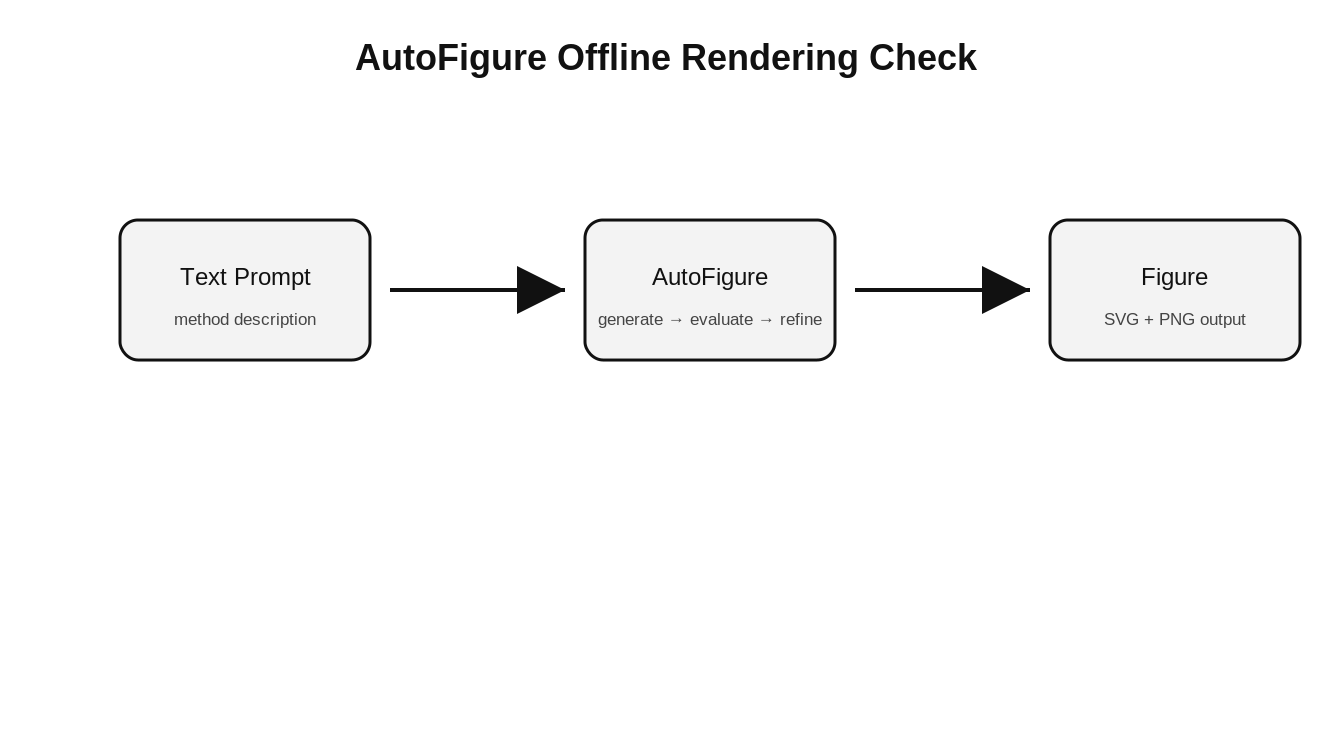


4. Creating a custom reference figure
Custom reference saved: /content/autofigure_colab_outputs/01_custom_references/reference_architecture_style.png


### Custom reference figure

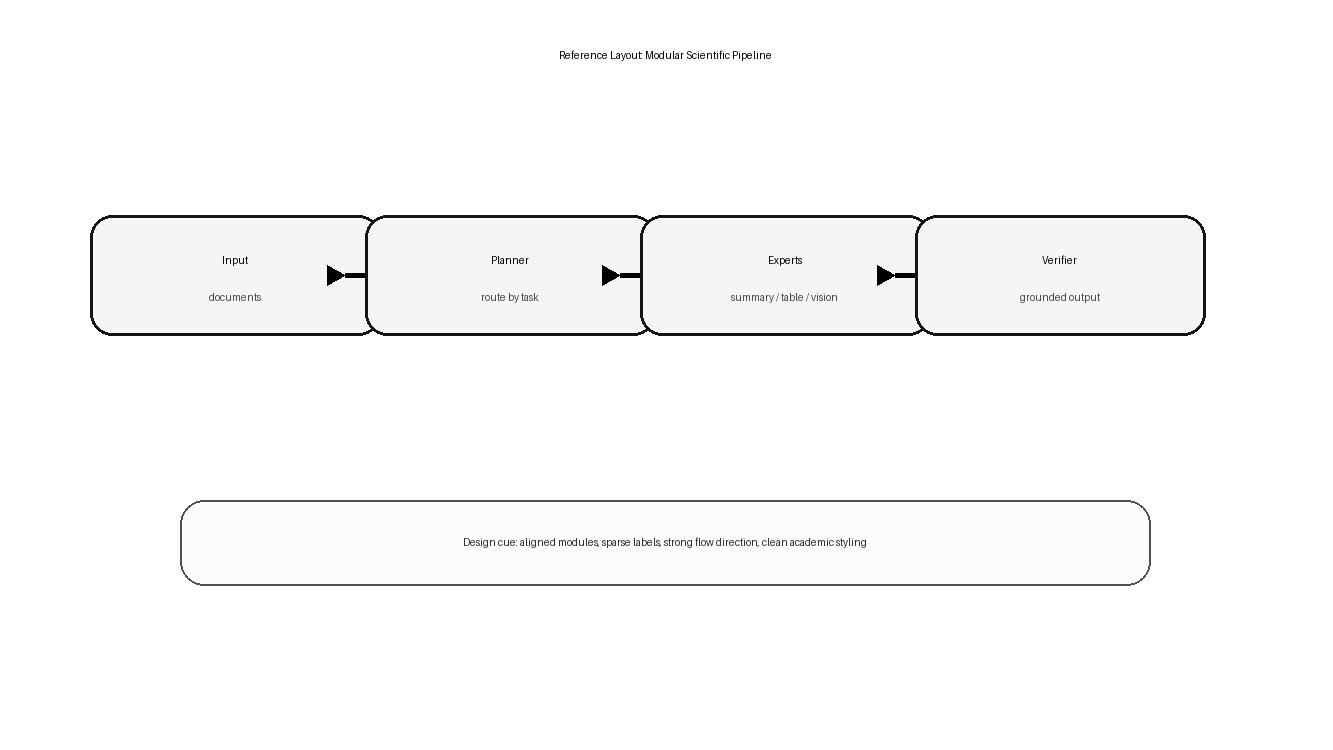


5. Configuring API-backed AutoFigure
Paste your openrouter API key, or press Enter to skip cloud generation: ··········
No API key provided. Cloud generation sections will be skipped.

6. Prompt template preview

You are a top-tier scientific figure layout designer. Please write SVG code based on the following paper content to visualize the core method the paper proposes as clear illustrations.

**Placeholder Specification:**
    *   To prepare for final illustration, an icon needs a placeholder.
    *   **Function**: The placeholder's role is to reserve space and provide a clear directive for the illustrator.
    *   **Recommended Implementation**: A clean, professional way to do this is with a gray, rounded-corner rectangle (`<rect rx="8" ry="8" style="fill:#cccccc; stroke:#666666; stroke-width:1;" />`).
    *   **Content (CRITICAL)**: Each placeholder MUST contain two pieces of text:
        *   **Exterior Label**: A concise name for the component, placed **outside** the box (e.g.,


Done.
If the model is unavailable or access is denied, change PROVIDER and GENERATION_MODEL near the top of the cell.


In [1]:
heading("8. Paper methodology extraction dry check")

paper_dir = OUTPUT_ROOT / "03_paper_to_figure"
paper_dir.mkdir(parents=True, exist_ok=True)

paper_md_path = paper_dir / "mini_paper.md"
paper_md_path.write_text(MINI_PAPER_MARKDOWN, encoding="utf-8")

if API_KEY:
    if RUN_PAPER_TO_FIGURE:
        extractor = MethodologyExtractor(config)
        extracted = extractor.extract_from_file(str(paper_md_path))

        print("\nExtracted methodology preview:")
        print((extracted or "")[:2500])
    else:
        print(f"Created demo paper markdown at: {paper_md_path}")
        print("Set RUN_PAPER_TO_FIGURE = True to run LLM methodology extraction and figure generation.")
else:
    print(f"Created demo paper markdown at: {paper_md_path}")
    print("No API key available, so LLM methodology extraction is skipped.")

if API_KEY and RUN_PAPER_TO_FIGURE:
    heading("9. Running paper-to-figure generation")

    paper_result = agent.generate_from_paper(
        paper_path=str(paper_md_path),
        max_iterations=MAX_ITERATIONS,
        output_format="svg",
        enable_enhancement=RUN_IMAGE_ENHANCEMENT,
        art_style=ART_STYLE,
        enhancement_input_type="code2prompt",
        enhancement_count=1,
        custom_references=[str(reference_path)],
        output_dir=str(paper_dir),
    )

    summarize_generation_result(paper_result, "Paper-to-Figure Result")

heading("10. Creating a tiny PDF and testing PDF text reading")

pdf_path = paper_dir / "mini_paper.pdf"

try:
    from reportlab.lib.pagesizes import letter
    from reportlab.pdfgen import canvas

    c = canvas.Canvas(str(pdf_path), pagesize=letter)
    width, height = letter
    y = height - 50

    for line in MINI_PAPER_MARKDOWN.splitlines():
        line = line.strip()

        if not line:
            y -= 12
            continue

        for wrapped in textwrap.wrap(line, width=95):
            c.drawString(50, y, wrapped)
            y -= 14

            if y < 60:
                c.showPage()
                y = height - 50

    c.save()

    print(f"Created demo PDF: {pdf_path}")

    if API_KEY:
        pdf_text = MethodologyExtractor(config)._read_pdf(pdf_path)
        print("PDF text extraction preview:")
        print((pdf_text or "")[:1500])
    else:
        print("PDF created. LLM-based paper-to-figure generation still requires an API key.")

except Exception as exc:
    print(f"PDF creation or read test failed: {exc}")

if API_KEY and RUN_MXGRAPH_DEMO:
    heading("11. Running editable mxGraph XML generation")

    mxgraph_dir = OUTPUT_ROOT / "04_mxgraph_drawio"
    mxgraph_dir.mkdir(parents=True, exist_ok=True)

    mx_result = agent.generate(
        description=FIGURE_DESCRIPTION,
        max_iterations=MAX_ITERATIONS,
        quality_threshold=QUALITY_THRESHOLD,
        output_format=MXGRAPH_OUTPUT_FORMAT,
        enable_enhancement=False,
        custom_references=[str(reference_path)],
        output_dir=str(mxgraph_dir),
        topic="paper",
    )

    summarize_generation_result(mx_result, "mxGraph / draw.io Result")

else:
    heading("11. mxGraph XML generation skipped")
    print("Set RUN_MXGRAPH_DEMO = True to generate editable draw.io mxGraph XML.")
    print("This path installs Chromium through Playwright and may be slower than SVG generation.")

heading("12. Output inventory and export")

all_files = []

for path in sorted(OUTPUT_ROOT.rglob("*")):
    if path.is_file():
        all_files.append(path)

print(f"Total files under {OUTPUT_ROOT}: {len(all_files)}")

for path in all_files:
    rel = path.relative_to(OUTPUT_ROOT)
    size_kb = path.stat().st_size / 1024
    print(f"{rel}  ({size_kb:.1f} KB)")

gallery_path = make_output_gallery(OUTPUT_ROOT)
print(f"\nGallery HTML: {gallery_path}")

zip_base = "/content/autofigure_colab_outputs"
zip_path = shutil.make_archive(zip_base, "zip", root_dir=str(OUTPUT_ROOT))
print(f"Zip archive: {zip_path}")

try:
    from IPython.display import display, HTML

    display(
        HTML(
            f"""
            <h3>AutoFigure tutorial complete</h3>
            <p><b>Output root:</b> {OUTPUT_ROOT}</p>
            <p><b>Gallery:</b> {gallery_path}</p>
            <p><b>Zip:</b> {zip_path}</p>
            """
        )
    )
except Exception:
    pass

print("\nDone.")
print("If the model is unavailable or access is denied, change PROVIDER and GENERATION_MODEL near the top of the cell.")